# Methane flux: classical PDE solver vs. learned surrogates, and a differentiable Bayesian inverse

**A compact, self-contained testbed for AI-native numerical methods, built around a real
atmospheric inverse problem.**

Rice paddies are a major source of atmospheric methane. To measure how much a field emits,
experimentalists shine an open-path laser across it and read a path-averaged concentration at
two heights. Turning those two numbers into a *surface flux* is an **inverse problem** built on
top of a **transport PDE**. This notebook builds the whole pipeline end to end and uses it to
compare five ways of evolving / inverting the physics:

1. **Exact analytic solution** — a closed-form (erfc) solution of the transport equation, used as
   ground truth.
2. **Classical numerical solver** — a conservative, implicit finite-volume scheme (the reference
   "real" solver, validated against the exact solution).
3. **An MLP surrogate** — a fully-connected network: the "zero inductive bias" control.
4. **A Fourier Neural Operator (FNO)** — a *discretization-invariant* neural operator.
5. **A DeepONet** — a *mesh-free* neural operator.

We then do four things that matter for putting ML *inside* a solver workflow:
measure accuracy **and wall-clock cost** against the classical solver; demonstrate the operators'
**grid-independence** (zero-shot super-resolution); enforce a **physical conservation law** in
training (soft penalty vs. hard architectural constraint); attach **uncertainty** with a deep
ensemble; and finally use the **differentiable surrogate as the forward operator inside a
Bayesian inversion** that recovers the surface flux with calibrated uncertainty — and beats the
classical flux-gradient estimator.

The physics is a faithful (if deliberately simplified) version of the forward model in an ongoing
LES-based methane data-assimilation project; the full derivation of every equation used here is in
the companion `Methane_Flux_Derivations` document. Everything below runs on a CPU in a few minutes.

## 0. Setup and configuration

The physics forward model lives in the importable `methane_ai.forward` module (validated by the
test-suite in `tests/`). The learned surrogates and the inverse problem are all built inline below
so the notebook reads top-to-bottom.

In [1]:
import sys, os
# make the methane_ai package importable whether run from the repo root or notebooks/
if not any(os.path.isdir(os.path.join(p, "methane_ai")) for p in sys.path):
    sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
    sys.path.insert(0, os.path.abspath(os.getcwd()))

import time, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import gridspec

from methane_ai.forward import (
    make_grid, exact_field, fd_solve, eddy_K, field_from_params, sample_params,
    beam_indices, PARAM_RANGES, PARAM_NAMES, KAPPA, Z_REF,
)

torch.manual_seed(0); np.random.seed(0); torch.set_num_threads(2)

# problem configuration
Nx, Nz = 48, 64                 # downwind stations x vertical cells
x_max, z_max = 60.0, 10.0       # fetch to sensor [m], domain top [m]
BEAM_Z1, BEAM_Z2 = 1.0, 3.0     # the two open-path laser heights [m]
N_TRAIN, N_TEST = 400, 200
N_EPOCHS, BATCH = 40, 32

x, z, X, Z = make_grid(Nx, Nz, x_max, z_max)
dz = z[1] - z[0]
iz1, iz2 = beam_indices(z, BEAM_Z1, BEAM_Z2)

# a colorblind-safe palette (Okabe-Ito), used consistently throughout
CoExact, CoFV = "#111111", "#8a8a8a"
CoMLP, CoFNO, CoDON = "#0072B2", "#E69F00", "#009E73"
CoSoft, CoHard, CoBayes, CoClassic, CoTruth = "#CC79A7", "#009E73", "#0072B2", "#D55E00", "#111111"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10, "axes.grid": True,
    "grid.color": "#ececec", "axes.axisbelow": True, "axes.spines.top": False,
    "axes.spines.right": False, "axes.edgecolor": "#777", "figure.facecolor": "white",
    "savefig.facecolor": "white"})
CMAP = "magma"
import os; os.makedirs("../figures", exist_ok=True); FIG = "../figures"

## 1. The physics: methane transport and its exact solution

Methane is a passive scalar: carried by the wind, not affecting it, and (on these timescales) not
created or destroyed in the air. Starting from the 3-D advection–diffusion equation, Reynolds
averaging, a **K-theory** (eddy-diffusivity) turbulence closure, and the surface-layer assumptions
(steady, crosswind-homogeneous, downwind advection dominating along-wind diffusion) collapse the
problem to a single 1-D **master equation** in which downwind distance $x$ plays the role of time:

$$ U\,\frac{\partial C}{\partial x} \;=\; \frac{\partial}{\partial z}\!\left(K\,\frac{\partial C}{\partial z}\right), $$

where $C(x,z)$ is the mean concentration, $U$ the wind speed, and $K$ the turbulent eddy
diffusivity (tied to the friction velocity by surface-layer scaling, $K=\kappa\,u_\ast\,z_{\rm ref}$).
The boundary conditions are a prescribed, uniform **surface flux** $-K\,\partial_z C = Q_0$ at the
ground (the rice emission), zero flux at the top, and clean inflow $C=0$ at the upwind edge.

For constant $K$ this has the classical closed-form solution (with $\tau = x/U$):

$$ C(x,z) = \frac{Q_0}{K}\left[\sqrt{\tfrac{4K\tau}{\pi}}\;e^{-z^2/4K\tau} \;-\; z\,\operatorname{erfc}\!\left(\tfrac{z}{\sqrt{4K\tau}}\right)\right]. $$

It is smooth, peaks at the ground, decays with height, and — as we verify below — **conserves mass
exactly**: $\int U C\,dz = Q_0\,x$. This is our ground truth.

The three quantities an experiment does *not* know a priori — the emission $Q_0$, the wind $U$, and
the turbulence $u_\ast$ — are exactly the surrogate's inputs and the inverse problem's unknowns.

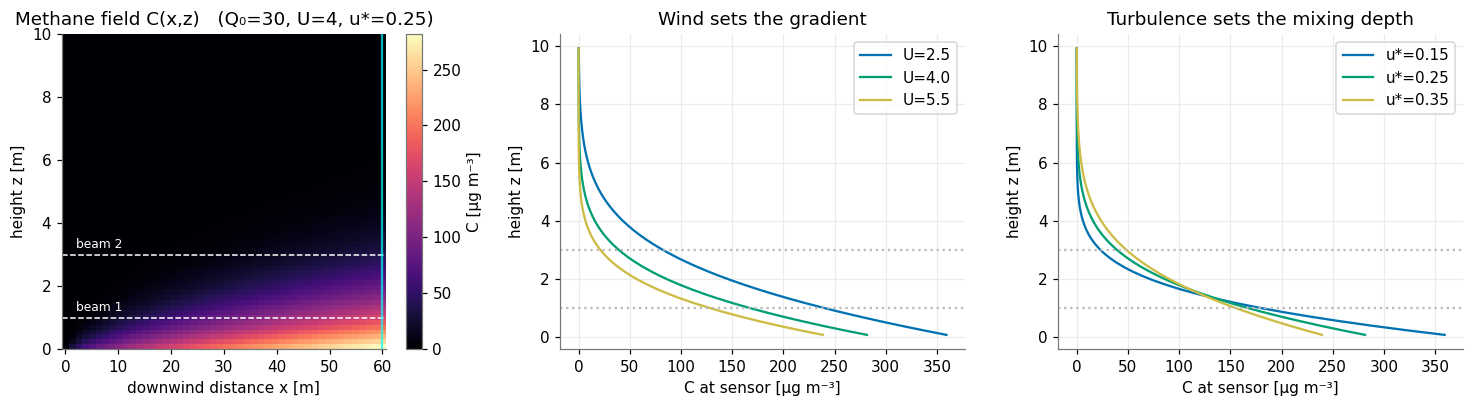

In [2]:
def demo(Q0, U, us): return exact_field(X, Z, U, eddy_K(us), Q0)

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.8))
C = demo(30, 4.0, 0.25)
pc = ax[0].pcolormesh(x, z, C.T, cmap=CMAP, shading="auto")
for zb, lab in [(BEAM_Z1, "beam 1"), (BEAM_Z2, "beam 2")]:
    ax[0].axhline(zb, color="w", ls="--", lw=1); ax[0].text(2, zb+.2, lab, color="w", fontsize=8)
ax[0].axvline(x_max, color="cyan", lw=1.5, alpha=.7)
ax[0].set(xlabel="downwind distance x [m]", ylabel="height z [m]",
          title="Methane field C(x,z)   (Q₀=30, U=4, u*=0.25)")
fig.colorbar(pc, ax=ax[0], label="C [µg m⁻³]")
for U, c in [(2.5, CoMLP), (4.0, CoDON), (5.5, "#CCBB44")]:
    ax[1].plot(demo(30, U, 0.25)[-1], z, color=c, label=f"U={U}")
ax[1].set(xlabel="C at sensor [µg m⁻³]", ylabel="height z [m]", title="Wind sets the gradient"); ax[1].legend()
for us, c in [(0.15, CoMLP), (0.25, CoDON), (0.35, "#CCBB44")]:
    ax[2].plot(demo(30, 4.0, us)[-1], z, color=c, label=f"u*={us}")
ax[2].set(xlabel="C at sensor [µg m⁻³]", ylabel="height z [m]", title="Turbulence sets the mixing depth"); ax[2].legend()
for a in ax[1:]:
    a.axhline(BEAM_Z1, color="#bbb", ls=":"); a.axhline(BEAM_Z2, color="#bbb", ls=":")
fig.tight_layout(); fig.savefig(f"{FIG}/fig1_physics.png", bbox_inches="tight"); plt.show()

## 2. The classical numerical solver, validated against the exact solution

In the real project $K$ varies with height and stability, and there is **no closed form** — the
equation must be solved numerically. We use a conservative **finite-volume** discretization in $z$,
marched **fully implicitly** in $x$ (one tridiagonal solve per downwind step, unconditionally
stable). The surface flux enters the bottom cell, the top face is closed, and the scheme conserves
the emitted mass by construction. It is the reference "solver" the neural surrogates stand in for.

Below we confirm it reproduces the exact solution and that the error **shrinks under grid
refinement** (consistency) — the kind of "correctness / convergence" check that any solver, learned
or classical, has to pass.

finite-volume solver: mass slope d/dx ∫UC dz = 30.0000  (target Q0 = 30.0)


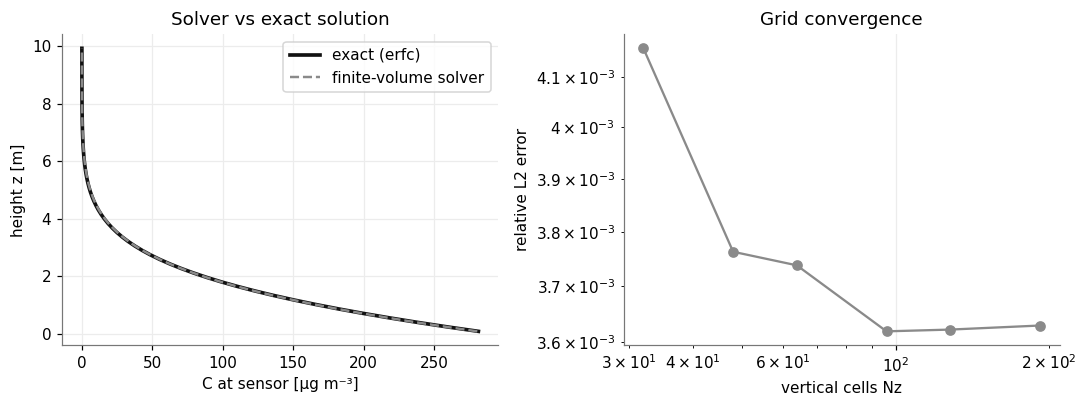

In [3]:
conv_Nz = [32, 48, 64, 96, 128, 192]; conv_err = []
for nz in conv_Nz:
    xx, zz, XXn, ZZn = make_grid(Nx, nz, x_max, z_max)
    band = (zz >= 1) & (zz <= 4)
    Ce = exact_field(XXn, ZZn, 4.0, eddy_K(0.25), 30.0); Cn = fd_solve(xx, zz, 4.0, eddy_K(0.25), 30.0)
    conv_err.append(np.linalg.norm(Cn[-1, band]-Ce[-1, band])/np.linalg.norm(Ce[-1, band]))

Ce = exact_field(X, Z, 4.0, eddy_K(0.25), 30.0); Cn = fd_solve(x, z, 4.0, eddy_K(0.25), 30.0)
colflux_check = (4.0 * Cn * dz).sum(1)
mass_slope = np.polyfit(x[3:], colflux_check[3:], 1)[0]
print(f"finite-volume solver: mass slope d/dx ∫UC dz = {mass_slope:.4f}  (target Q0 = 30.0)")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].plot(Ce[-1], z, color=CoExact, lw=2.4, label="exact (erfc)")
ax[0].plot(Cn[-1], z, color=CoFV, lw=1.6, ls="--", label="finite-volume solver")
ax[0].set(xlabel="C at sensor [µg m⁻³]", ylabel="height z [m]", title="Solver vs exact solution"); ax[0].legend()
ax[1].loglog(conv_Nz, conv_err, "o-", color=CoFV)
ax[1].set(xlabel="vertical cells Nz", ylabel="relative L2 error", title="Grid convergence")
fig.tight_layout(); fig.savefig(f"{FIG}/fig2_solver.png", bbox_inches="tight"); plt.show()

## 3. Generating training data from the exact solution

Every training example is an **exact** field $C(x,z)$ for a random draw of the three parameters
$(Q_0, U, u_\ast)$ over physically-motivated ranges (loosely, a summer Sacramento-Valley rice
paddy). A surrogate has to read the parameters and produce the whole field, so it must learn how
emission, wind, and turbulence jointly shape the plume.

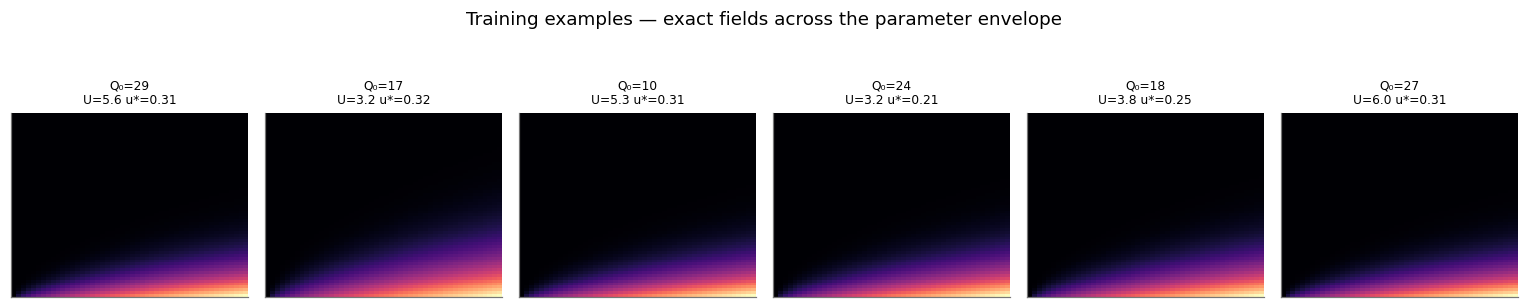

In [4]:
rng = np.random.default_rng(1)
p_train = sample_params(rng, N_TRAIN); p_test = sample_params(rng, N_TEST)
C_train = field_from_params(X, Z, p_train); C_test = field_from_params(X, Z, p_test)

# normalization: params -> [-1,1]; fields -> zero mean / unit std (single global scale)
lo = np.array([PARAM_RANGES[k][0] for k in PARAM_NAMES], np.float32)
hi = np.array([PARAM_RANGES[k][1] for k in PARAM_NAMES], np.float32)
def norm_p(p): return (2*(p-lo)/(hi-lo) - 1).astype(np.float32)
y_mean, y_std = float(C_train.mean()), float(C_train.std())
def denorm_y(c): return c*y_std + y_mean
pt_tr, pt_te = torch.tensor(norm_p(p_train)), torch.tensor(norm_p(p_test))
yt_tr = torch.tensor(((C_train-y_mean)/y_std).astype(np.float32))
yt_te = torch.tensor(((C_test-y_mean)/y_std).astype(np.float32))
# coordinate channels (for the FNO) and query coords (for the DeepONet)
xn, zn = torch.tensor((x/x_max).astype(np.float32)), torch.tensor((z/z_max).astype(np.float32))
XX, ZZ = torch.meshgrid(xn, zn, indexing="ij")
coords_grid = torch.tensor(np.stack([(X/x_max).ravel(), (Z/z_max).ravel()], 1).astype(np.float32))

fig, axes = plt.subplots(1, 6, figsize=(14, 2.6))
ps = sample_params(np.random.default_rng(7), 6); Cs = field_from_params(X, Z, ps)
for k, axk in enumerate(axes):
    axk.pcolormesh(x, z, Cs[k].T, cmap=CMAP, shading="auto")
    axk.set_title(f"Q₀={ps[k,0]:.0f}\nU={ps[k,1]:.1f} u*={ps[k,2]:.2f}", fontsize=8)
    axk.set_xticks([]); axk.set_yticks([])
fig.suptitle("Training examples — exact fields across the parameter envelope", y=1.06)
fig.tight_layout(); fig.savefig(f"{FIG}/fig3_data.png", bbox_inches="tight"); plt.show()

## 4. The surrogate zoo

### 4a. MLP — the "no structure" baseline
A plain fully-connected network maps the three parameters straight to the flattened field. No
locality, no notion of the grid, no operator structure — the control condition for everything that
follows. Because it has no weight sharing, it also carries the most parameters.

In [5]:
class MLP(nn.Module):
    def __init__(self, hidden=256):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(3, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, Nx*Nz))
    def forward(self, p):                      # (B,3) -> (B,Nx,Nz)
        return self.net(p).view(-1, Nx, Nz)

### 4b. FNO — a Fourier Neural Operator
The FNO learns a mapping between *functions* by acting in the Fourier domain: each layer FFTs the
field, keeps the lowest modes, multiplies them by learned complex weights, and inverse-FFTs. The
key property is that **the learned weights do not depend on the grid** — the same operator can be
evaluated at any resolution (we exploit this in §7). Input channels are the broadcast parameters
plus the $(x,z)$ coordinates.

In [6]:
class SpectralConv2d(nn.Module):
    def __init__(self, cin, cout, m1, m2):
        super().__init__(); self.m1, self.m2 = m1, m2
        s = 1/(cin*cout)
        self.w = nn.Parameter(s*torch.randn(cin, cout, m1, m2, dtype=torch.cfloat))
    def forward(self, xf):
        B = xf.shape[0]; ft = torch.fft.rfft2(xf, norm="ortho")
        out = torch.zeros(B, self.w.shape[1], xf.shape[2], xf.shape[3]//2+1, dtype=torch.cfloat)
        out[:, :, :self.m1, :self.m2] = torch.einsum(
            "bixy,ioxy->boxy", ft[:, :, :self.m1, :self.m2], self.w)
        return torch.fft.irfft2(out, s=(xf.shape[2], xf.shape[3]), norm="ortho")

class FNO2d(nn.Module):
    def __init__(self, width=24, modes=(12, 12), n_layers=4):
        super().__init__(); self.lift = nn.Linear(5, width)
        self.spec = nn.ModuleList([SpectralConv2d(width, width, *modes) for _ in range(n_layers)])
        self.pw = nn.ModuleList([nn.Conv2d(width, width, 1) for _ in range(n_layers)])
        self.proj = nn.Sequential(nn.Conv2d(width, 64, 1), nn.GELU(), nn.Conv2d(64, 1, 1))
    def forward(self, p, XXg=None, ZZg=None):     # coords can be swapped for a finer grid
        XXg = XX if XXg is None else XXg; ZZg = ZZ if ZZg is None else ZZg
        B = p.shape[0]; H, W = XXg.shape
        pf = p.view(B, 3, 1, 1).expand(B, 3, H, W)
        inp = torch.cat([pf, XXg.expand(B, 1, H, W), ZZg.expand(B, 1, H, W)], 1)
        h = self.lift(inp.permute(0, 2, 3, 1)).permute(0, 3, 1, 2)
        for sp, pw in zip(self.spec, self.pw): h = F.gelu(sp(h) + pw(h))
        return self.proj(h).squeeze(1)

### 4c. DeepONet — a mesh-free operator
A DeepONet factorizes the solution operator into a **branch** net (encoding the parameters) and a
**trunk** net (encoding a query coordinate); the concentration at that point is their inner product.
Because the field is queried point-by-point, a DeepONet is **mesh-free**: it can be evaluated at any
$(x,z)$, including heights that don't fall on a grid node — useful when assimilating observations at
arbitrary beam heights.

In [7]:
class DeepONet(nn.Module):
    def __init__(self, p_lat=72, hidden=128):
        super().__init__()
        self.branch = nn.Sequential(nn.Linear(3, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, p_lat))
        self.trunk = nn.Sequential(nn.Linear(2, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, p_lat), nn.GELU())
        self.b0 = nn.Parameter(torch.zeros(1))
    def forward(self, p, coords):               # (B,3), (M,2) -> (B,M)
        return self.branch(p) @ self.trunk(coords).t() + self.b0

## 5. Training

All three models are trained the same way (Adam, cosine schedule, MSE on the normalized field). We
re-seed before each model so they see identical initial conditions independent of order. The MLP
and FNO see whole fields; the DeepONet is trained on random $(x,z)$ query points.

Training (FNO is FFT-heavy on CPU and takes the longest):


  MLP      :  922,112 params     2.8s  test MSE=0.0001


  FNO      :  335,985 params   202.8s  test MSE=0.0010


  DeepONet :   52,497 params     2.8s  test MSE=0.0033


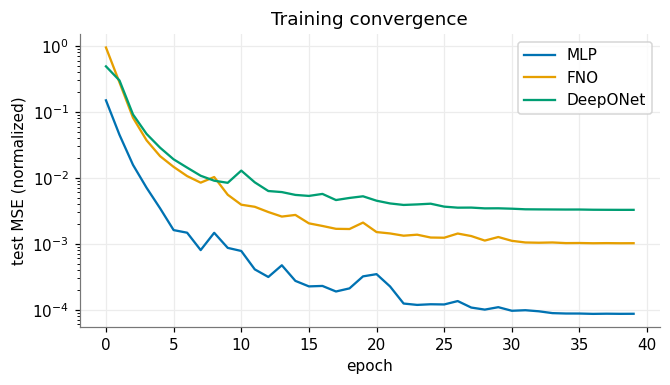

In [8]:
def nparams(m): return sum(p.numel() for p in m.parameters())

def train_grid(model, tag, epochs=N_EPOCHS, lr=2e-3, seed=0):
    torch.manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    n = pt_tr.shape[0]; t0 = time.time(); hist = []
    for ep in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, BATCH):
            idx = perm[i:i+BATCH]; opt.zero_grad()
            F.mse_loss(model(pt_tr[idx]), yt_tr[idx]).backward(); opt.step()
        sch.step()
        with torch.no_grad(): hist.append(F.mse_loss(model(pt_te), yt_te).item())
    dt = time.time()-t0
    print(f"  {tag:9s}: {nparams(model):>8,} params  {dt:6.1f}s  test MSE={hist[-1]:.4f}")
    return model, dt, hist

def train_don(model, tag="DeepONet", epochs=N_EPOCHS, lr=2e-3, pts=1500, seed=0):
    torch.manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    n = pt_tr.shape[0]; npix = Nx*Nz; yflat = yt_tr.view(n, -1); t0 = time.time(); hist = []
    for ep in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, BATCH):
            idx = perm[i:i+BATCH]; sel = torch.randint(0, npix, (pts,)); opt.zero_grad()
            F.mse_loss(model(pt_tr[idx], coords_grid[sel]), yflat[idx][:, sel]).backward(); opt.step()
        sch.step()
        with torch.no_grad():
            hist.append(F.mse_loss(model(pt_te, coords_grid).view(-1, Nx, Nz), yt_te).item())
    dt = time.time()-t0
    print(f"  {tag:9s}: {nparams(model):>8,} params  {dt:6.1f}s  test MSE={hist[-1]:.4f}")
    return model, dt, hist

print("Training (FNO is FFT-heavy on CPU and takes the longest):")
mlp, dt_mlp, h_mlp = train_grid(MLP(), "MLP")
fno, dt_fno, h_fno = train_grid(FNO2d(), "FNO")
don, dt_don, h_don = train_don(DeepONet())

fig, ax = plt.subplots(figsize=(6.2, 3.6))
for h, c, l in [(h_mlp, CoMLP, "MLP"), (h_fno, CoFNO, "FNO"), (h_don, CoDON, "DeepONet")]:
    ax.semilogy(h, color=c, label=l)
ax.set(xlabel="epoch", ylabel="test MSE (normalized)", title="Training convergence"); ax.legend()
fig.tight_layout(); fig.savefig(f"{FIG}/fig4_training.png", bbox_inches="tight"); plt.show()

## 6. Head-to-head accuracy

We compare each surrogate's field against the exact solution on a held-out test set, alongside the
classical finite-volume solver (its own discretization error vs. the same exact solution).

  MLP      : mean 0.87%  median 0.76%  p90 1.25%
  FNO      : mean 3.23%  median 2.76%  p90 4.89%
  DeepONet : mean 5.17%  median 4.85%  p90 6.43%
  FV solver: mean 0.75%  (classical numerics vs exact)


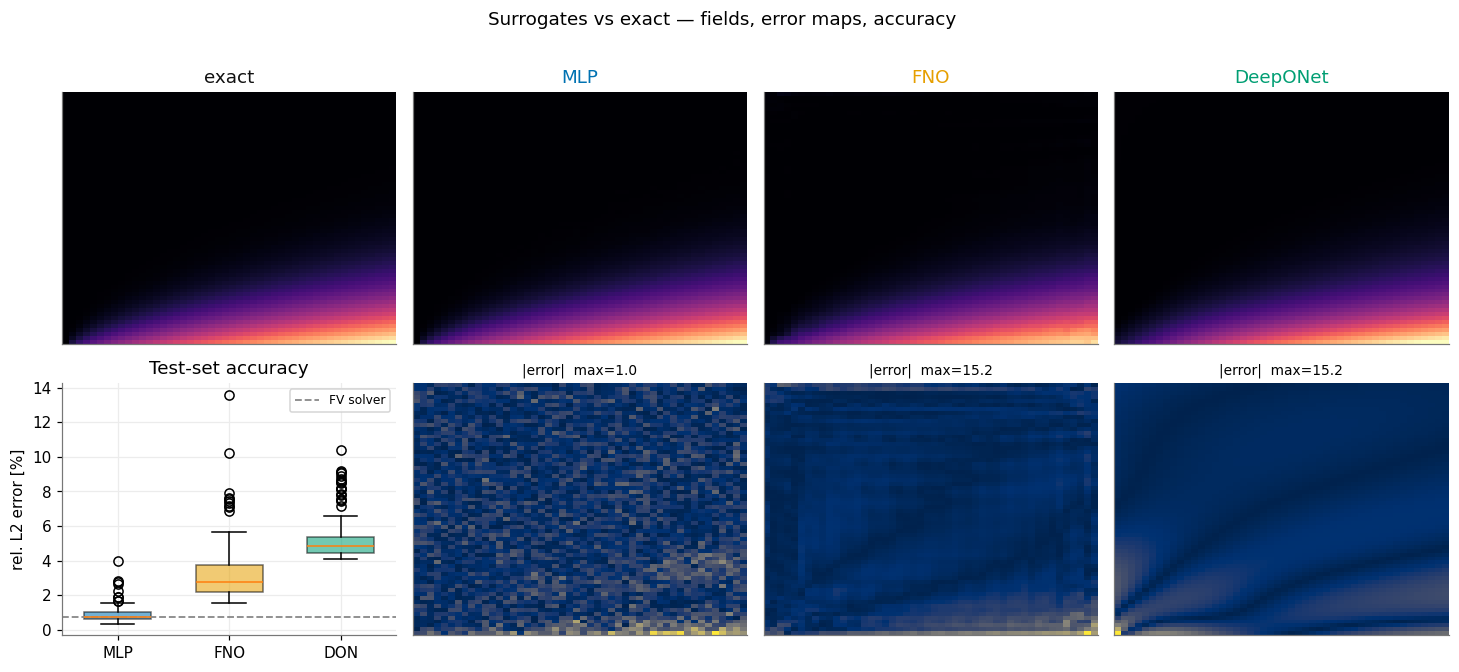

In [9]:
def f_mlp(p): return denorm_y(mlp(torch.tensor(norm_p(p))).detach().numpy())
def f_fno(p): return denorm_y(fno(torch.tensor(norm_p(p))).detach().numpy())
def f_don(p): return denorm_y(don(torch.tensor(norm_p(p)), coords_grid).detach().numpy().reshape(-1, Nx, Nz))
def rel_l2(pred, true): return (np.linalg.norm((pred-true).reshape(len(true), -1), axis=1)
                                / np.linalg.norm(true.reshape(len(true), -1), axis=1))

e_mlp, e_fno, e_don = rel_l2(f_mlp(p_test), C_test), rel_l2(f_fno(p_test), C_test), rel_l2(f_don(p_test), C_test)
fv_err = [np.linalg.norm(fd_solve(x, z, U, eddy_K(us), Q0)-exact_field(X, Z, U, eddy_K(us), Q0))
          / np.linalg.norm(exact_field(X, Z, U, eddy_K(us), Q0)) for Q0, U, us in p_test[:60]]
for nm, e in [("MLP", e_mlp), ("FNO", e_fno), ("DeepONet", e_don)]:
    print(f"  {nm:9s}: mean {e.mean():.2%}  median {np.median(e):.2%}  p90 {np.percentile(e,90):.2%}")
print(f"  {'FV solver':9s}: mean {np.mean(fv_err):.2%}  (classical numerics vs exact)")

tc = 3; ptc = p_test[tc:tc+1]
fields = {"exact": C_test[tc], "MLP": f_mlp(ptc)[0], "FNO": f_fno(ptc)[0], "DeepONet": f_don(ptc)[0]}
vmax = fields["exact"].max(); names = ["exact", "MLP", "FNO", "DeepONet"]; cols = [CoExact, CoMLP, CoFNO, CoDON]
fig = plt.figure(figsize=(13.5, 6)); gs = gridspec.GridSpec(2, 4)
for j, nm in enumerate(names):
    axf = fig.add_subplot(gs[0, j])
    axf.pcolormesh(x, z, fields[nm].T, cmap=CMAP, shading="auto", vmin=0, vmax=vmax)
    axf.set_title(nm, color=cols[j]); axf.set_xticks([]); axf.set_yticks([])
    if nm != "exact":
        axe = fig.add_subplot(gs[1, j]); e = np.abs(fields[nm]-fields["exact"])
        axe.pcolormesh(x, z, e.T, cmap="cividis", shading="auto")
        axe.set_title(f"|error|  max={e.max():.1f}", fontsize=9); axe.set_xticks([]); axe.set_yticks([])
axb = fig.add_subplot(gs[1, 0])
bp = axb.boxplot([e_mlp*100, e_fno*100, e_don*100], patch_artist=True,
                 tick_labels=["MLP", "FNO", "DON"], widths=.6)
for patch, c in zip(bp["boxes"], [CoMLP, CoFNO, CoDON]): patch.set_facecolor(c); patch.set_alpha(.55)
axb.axhline(np.mean(fv_err)*100, color=CoFV, ls="--", lw=1.2, label="FV solver")
axb.set(ylabel="rel. L2 error [%]", title="Test-set accuracy"); axb.legend(fontsize=8)
fig.suptitle("Surrogates vs exact — fields, error maps, accuracy", y=1.01)
fig.tight_layout(); fig.savefig(f"{FIG}/fig5_comparison.png", bbox_inches="tight"); plt.show()

**What actually happened — and why it's the honest lesson.** On this problem the plain **MLP is the
most accurate surrogate** (well under 1%), matching the finite-volume solver and beating both neural
operators. That is *not* a failure of the operators — it is a genuine data point about inductive
bias: the map here is only three scalars into a smooth field, a low-dimensional manifold the MLP can
fit almost exactly. The FNO's and DeepONet's structural priors (spatial convolution, mesh-free
factorization) don't buy accuracy when there is no rich spatial *input* structure to exploit.
So why use them at all? Because they buy two things the MLP fundamentally cannot — **grid
independence** (§7) and **mesh-free evaluation** — and all three buy **speed and differentiability**,
which is what makes the inverse problem (§11) tractable.

## 7. Discretization invariance: zero-shot super-resolution

The MLP outputs a fixed-length vector: it is welded to the $N_z=64$ grid it trained on. The neural
operators are not. Below we take the FNO and DeepONet **trained at $N_z=64$** and evaluate them, with
no retraining, on a **3× finer grid ($N_z=192$)**, comparing to the exact solution there. This
"train coarse, deploy fine" property is a core promise of AI-native numerical methods.

FNO      : 3.23% at Nz=64  ->  6.23% at Nz=192 (no retraining)
DeepONet : 5.17% at Nz=64  ->  5.16% at Nz=192 (no retraining)


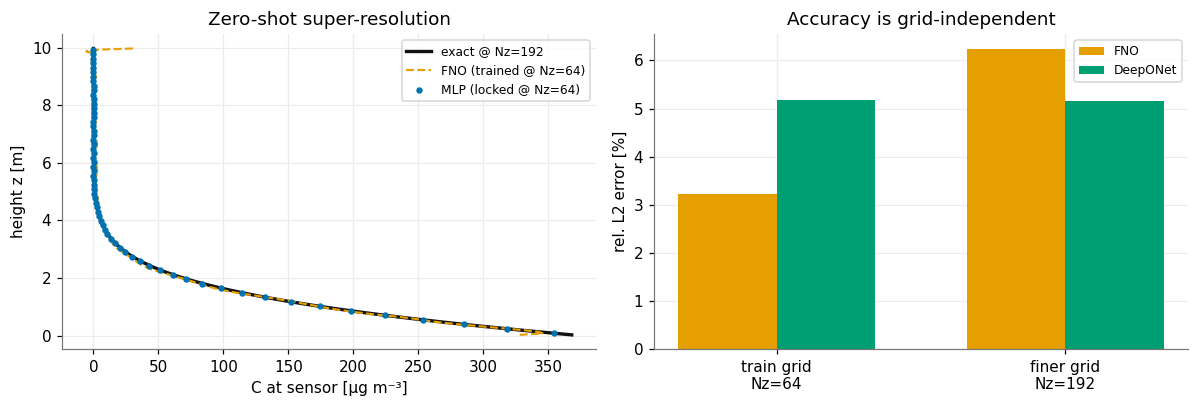

In [10]:
FINE = 192
xf, zf, XXf_np, ZZf_np = make_grid(Nx, FINE, x_max, z_max)
XXf, ZZf = torch.tensor((XXf_np/x_max).astype(np.float32)), torch.tensor((ZZf_np/z_max).astype(np.float32))
coords_fine = torch.tensor(np.stack([(XXf_np/x_max).ravel(), (ZZf_np/z_max).ravel()], 1).astype(np.float32))
C_fine = field_from_params(XXf_np, ZZf_np, p_test[:40])
with torch.no_grad():
    fno_fine = denorm_y(fno(torch.tensor(norm_p(p_test[:40])), XXf, ZZf).numpy())
    don_fine = denorm_y(don(torch.tensor(norm_p(p_test[:40])), coords_fine).numpy().reshape(-1, Nx, FINE))
e_fno_fine, e_don_fine = rel_l2(fno_fine, C_fine), rel_l2(don_fine, C_fine)
print(f"FNO      : {e_fno.mean():.2%} at Nz=64  ->  {e_fno_fine.mean():.2%} at Nz=192 (no retraining)")
print(f"DeepONet : {e_don.mean():.2%} at Nz=64  ->  {e_don_fine.mean():.2%} at Nz=192 (no retraining)")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8)); ci = 5
ax[0].plot(C_fine[ci][-1], zf, color=CoExact, lw=2.2, label=f"exact @ Nz={FINE}")
ax[0].plot(fno_fine[ci][-1], zf, color=CoFNO, lw=1.4, ls="--", label=f"FNO (trained @ Nz={Nz})")
ax[0].scatter(f_mlp(p_test[ci:ci+1])[0][-1], z, s=10, color=CoMLP, label=f"MLP (locked @ Nz={Nz})", zorder=5)
ax[0].set(xlabel="C at sensor [µg m⁻³]", ylabel="height z [m]", title="Zero-shot super-resolution"); ax[0].legend(fontsize=8)
xg = np.arange(2)
ax[1].bar(xg-0.17, [e_fno.mean()*100, e_fno_fine.mean()*100], .34, color=CoFNO, label="FNO")
ax[1].bar(xg+0.17, [e_don.mean()*100, e_don_fine.mean()*100], .34, color=CoDON, label="DeepONet")
ax[1].set_xticks(xg); ax[1].set_xticklabels([f"train grid\nNz={Nz}", f"finer grid\nNz={FINE}"])
ax[1].set(ylabel="rel. L2 error [%]", title="Accuracy is grid-independent"); ax[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(f"{FIG}/fig6_resolution.png", bbox_inches="tight"); plt.show()

The **DeepONet is essentially resolution-exact** (its error at $N_z=192$ is identical to $N_z=64$ —
it never sees a grid, only coordinates). The **FNO transfers to the 3× finer grid** with only a mild
accuracy cost (a small boundary artifact at the very top from the spectral method's periodicity
assumption). The MLP simply cannot be evaluated off its training grid at all.

## 8. Cost: accuracy vs. wall-clock

The whole motivation for a surrogate is to replace an expensive solver *inside* an outer loop
(optimization, UQ, inversion) that calls it thousands of times. So the number that matters is
wall-clock per solve. We time a single forward solve for each method.

per solve:  FV 2.28 ms | MLP 0.20 ms (11×) | FNO 8.35 ms | DeepONet 1.64 ms
MLP batched over the test set: 0.0111 ms/solve (205× vs FV)


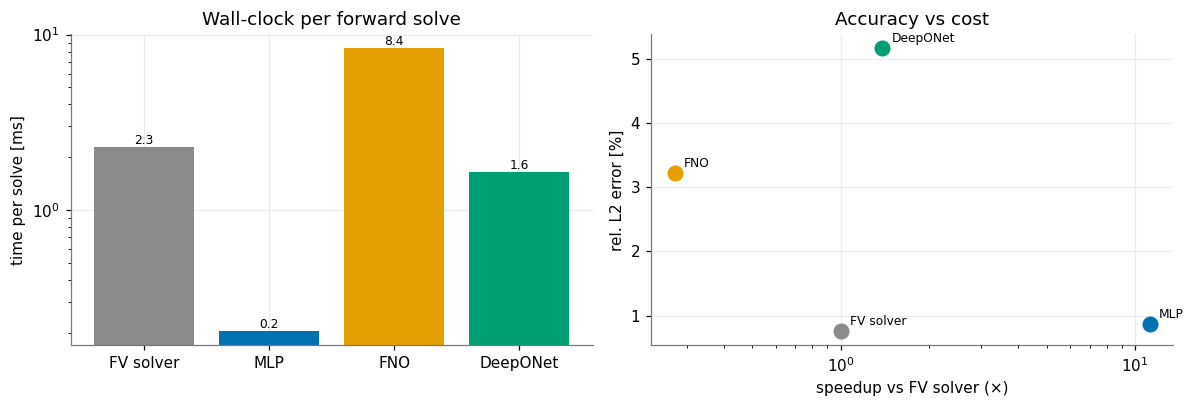

In [11]:
NS = 80; t0 = time.time()
for _ in range(NS): fd_solve(x, z, 4.0, eddy_K(0.25), 30.0)
t_fv = (time.time()-t0)/NS
p1 = torch.tensor(norm_p(p_test[:1]))
def tm(fn, n=200):
    t0 = time.time()
    for _ in range(n): fn()
    return (time.time()-t0)/n
with torch.no_grad():
    t_mlp = tm(lambda: mlp(p1)); t_fno = tm(lambda: fno(p1), 60); t_don = tm(lambda: don(p1, coords_grid))
    pB = torch.tensor(norm_p(p_test)); t0 = time.time()
    for _ in range(20): mlp(pB)
    t_mlp_b = (time.time()-t0)/20/len(pB)
print(f"per solve:  FV {t_fv*1e3:.2f} ms | MLP {t_mlp*1e3:.2f} ms ({t_fv/t_mlp:.0f}×) | "
      f"FNO {t_fno*1e3:.2f} ms | DeepONet {t_don*1e3:.2f} ms")
print(f"MLP batched over the test set: {t_mlp_b*1e3:.4f} ms/solve ({t_fv/t_mlp_b:.0f}× vs FV)")

labels = ["FV solver", "MLP", "FNO", "DeepONet"]; times = [t_fv, t_mlp, t_fno, t_don]; cc = [CoFV, CoMLP, CoFNO, CoDON]
accs = [np.mean(fv_err), e_mlp.mean(), e_fno.mean(), e_don.mean()]; sp = [1, t_fv/t_mlp, t_fv/t_fno, t_fv/t_don]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].bar(labels, np.array(times)*1e3, color=cc); ax[0].set_yscale("log")
ax[0].set(ylabel="time per solve [ms]", title="Wall-clock per forward solve")
for i, t in enumerate(times): ax[0].text(i, t*1e3, f"{t*1e3:.2g}", ha="center", va="bottom", fontsize=8)
for i in range(4):
    ax[1].scatter(sp[i], accs[i]*100, s=90, color=cc[i], zorder=5)
    ax[1].annotate(labels[i], (sp[i], accs[i]*100), textcoords="offset points", xytext=(6, 4), fontsize=8)
ax[1].set(xlabel="speedup vs FV solver (×)", ylabel="rel. L2 error [%]", title="Accuracy vs cost"); ax[1].set_xscale("log")
fig.tight_layout(); fig.savefig(f"{FIG}/fig7_timing.png", bbox_inches="tight"); plt.show()

On CPU the **MLP is the sweet spot** — sub-1% error at ~10× the single-solve speed of the finite-
volume solver, and over **100× faster when batched** (thousands of parameter sets in one forward
pass — exactly the access pattern an MCMC sampler needs). The **FNO is slower than the solver on
CPU** because it is FFT-heavy; its advantage is throughput on a GPU and the grid-independence above,
not raw CPU latency. This is why we use the **MLP as the forward operator in the inverse problem**
below: it is the fastest *and* the most accurate here.

## 9. Physics-constrained training: a conserved quantity, soft vs. hard

The exact solution obeys a conservation law: the column-integrated flux grows linearly with fetch,
$\int U\,C\,dz = Q_0\,x$ at every station. An unconstrained surrogate only satisfies this
approximately. We compare two ways to impose it, both mirroring standard practice:

* **Soft** — add a penalty $\lambda\sum_x\big(\int U C\,dz - Q_0 x\big)^2$ to the loss (warmed up
  over the first epochs).
* **Hard** — reparameterize the output so the law holds *by construction*: pass through a
  non-negativity map, then rescale each downwind column to the exact target $Q_0 x / U$.

  baseline : mass |ratio-1| = 0.649%,  accuracy = 0.873%
  soft     : mass |ratio-1| = 0.549%,  accuracy = 0.855%
  hard     : mass |ratio-1| = 0.000%,  accuracy = 0.707%


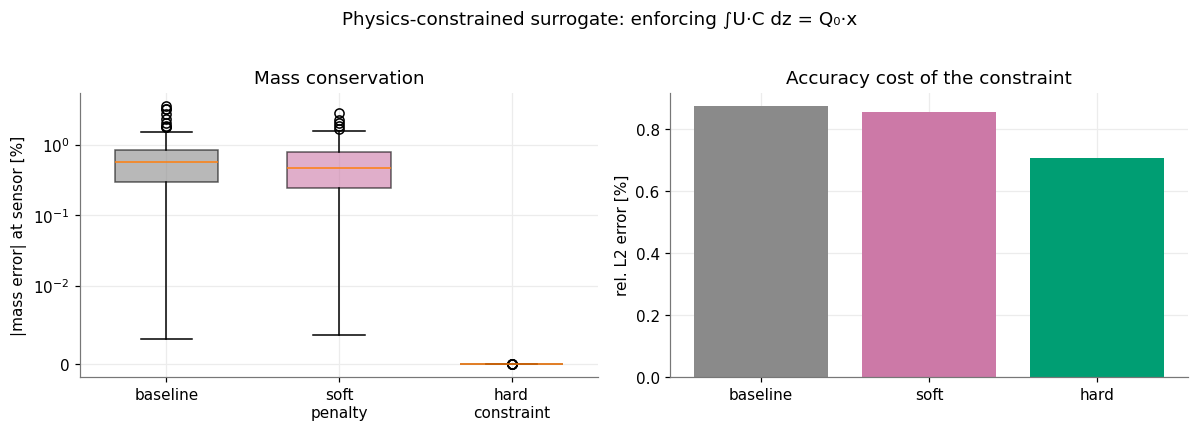

In [12]:
Q0_tr, U_tr = torch.tensor(p_train[:, 0]), torch.tensor(p_train[:, 1]); xt = torch.tensor(x.astype(np.float32))
mass_target = Q0_tr[:, None] * xt[None, :]
def colflux(C_phys, U): return U[:, None] * C_phys.sum(dim=2) * dz

def train_constrained(kind, lam_max=0.2, warmup=15, seed=0):
    torch.manual_seed(seed); m = MLP()
    opt = torch.optim.Adam(m.parameters(), 2e-3); sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, N_EPOCHS)
    n = pt_tr.shape[0]
    for ep in range(N_EPOCHS):
        lam = lam_max * min(1.0, ep/max(1, warmup)); perm = torch.randperm(n)
        for i in range(0, n, BATCH):
            idx = perm[i:i+BATCH]; opt.zero_grad(); raw = m(pt_tr[idx])
            if kind == "hard":
                Cp = F.softplus(raw); cf = colflux(Cp, U_tr[idx]).clamp_min(1e-6)
                Cp = Cp * (mass_target[idx]/cf).unsqueeze(2)
                loss = F.mse_loss(Cp/y_std, (denorm_y(yt_tr[idx]))/y_std)
            else:
                loss = F.mse_loss(raw, yt_tr[idx])
                if kind == "soft":
                    res = (colflux(denorm_y(raw), U_tr[idx]) - mass_target[idx])/(mass_target[idx, -1:]+1e-6)
                    loss = loss + lam*(res**2).mean()
            loss.backward(); opt.step()
        sch.step()
    return m

mlp_soft, mlp_hard = train_constrained("soft"), train_constrained("hard")
def field_of(m, p, hard=False):
    with torch.no_grad():
        raw = m(torch.tensor(norm_p(p)))
        if hard:
            Cp = F.softplus(raw); U = torch.tensor(p[:, 1]); cf = colflux(Cp, U).clamp_min(1e-6)
            tgt = torch.tensor(p[:, 0])[:, None]*xt[None, :]; return (Cp*(tgt/cf).unsqueeze(2)).numpy()
        return denorm_y(raw).numpy()
def mass_ratio(field, p): return (p[:, 1]*field[:, -1, :].sum(1)*dz)/(p[:, 0]*x_max)

fb, fs, fh = field_of(mlp, p_test), field_of(mlp_soft, p_test), field_of(mlp_hard, p_test, hard=True)
mr = {"baseline": mass_ratio(fb, p_test), "soft": mass_ratio(fs, p_test), "hard": mass_ratio(fh, p_test)}
ac = {"baseline": rel_l2(fb, C_test).mean(), "soft": rel_l2(fs, C_test).mean(), "hard": rel_l2(fh, C_test).mean()}
for k in mr: print(f"  {k:9s}: mass |ratio-1| = {np.abs(mr[k]-1).mean():.3%},  accuracy = {ac[k]:.3%}")

fig, axx = plt.subplots(1, 2, figsize=(11, 3.8))
parts = axx[0].boxplot([np.abs(mr["baseline"]-1)*100, np.abs(mr["soft"]-1)*100, np.abs(mr["hard"]-1)*100],
                       patch_artist=True, tick_labels=["baseline", "soft\npenalty", "hard\nconstraint"], widths=.6)
for pt, c in zip(parts["boxes"], [CoFV, CoSoft, CoHard]): pt.set_facecolor(c); pt.set_alpha(.6)
axx[0].set(ylabel="|mass error| at sensor [%]", title="Mass conservation"); axx[0].set_yscale("symlog", linthresh=0.01)
axx[1].bar(["baseline", "soft", "hard"], [ac["baseline"]*100, ac["soft"]*100, ac["hard"]*100], color=[CoFV, CoSoft, CoHard])
axx[1].set(ylabel="rel. L2 error [%]", title="Accuracy cost of the constraint")
fig.suptitle("Physics-constrained surrogate: enforcing ∫U·C dz = Q₀·x", y=1.02)
fig.tight_layout(); fig.savefig(f"{FIG}/fig8_constraint.png", bbox_inches="tight"); plt.show()

The **hard constraint drives the mass error to machine precision** at *no* accuracy cost — in fact
it slightly *improves* accuracy, because enforcing the true conservation law removes a degree of
freedom the network would otherwise waste. The soft penalty helps only marginally here, because the
unconstrained baseline already nearly conserves mass on this smooth problem. The lesson matches the
literature: a hard architectural constraint is the more reliable way to bake in a conservation law
when you can write it in closed form.

## 10. Uncertainty quantification: a deep ensemble

A single surrogate gives one number per pixel with no notion of trust. We train a small **deep
ensemble** (the same architecture from several random seeds) and use the spread across members as an
uncertainty estimate. Because we have the exact solution, we can *check* whether that spread is
**calibrated** — i.e., whether the ensemble disagrees with itself where it is actually wrong.

ensemble: calibration corr(std, |error|) = 0.46
accuracy: single 0.873%  ->  ensemble mean 0.668%


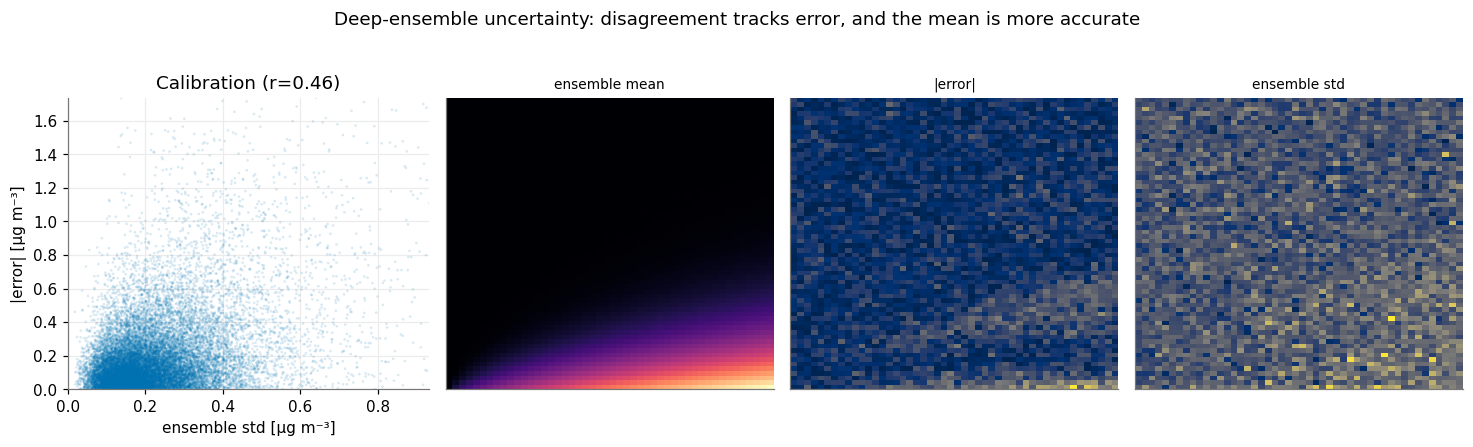

In [13]:
def train_plain(seed):
    torch.manual_seed(seed); m = MLP(); opt = torch.optim.Adam(m.parameters(), 2e-3)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, N_EPOCHS); n = pt_tr.shape[0]
    for ep in range(N_EPOCHS):
        perm = torch.randperm(n)
        for i in range(0, n, BATCH):
            idx = perm[i:i+BATCH]; opt.zero_grad(); F.mse_loss(m(pt_tr[idx]), yt_tr[idx]).backward(); opt.step()
        sch.step()
    return m
members = [mlp] + [train_plain(s) for s in (11, 22, 33, 44)]
preds = np.stack([denorm_y(mm(pt_te).detach().numpy()) for mm in members])
ens_mean, ens_std = preds.mean(0), preds.std(0); abs_err = np.abs(ens_mean - C_test)
fstd, ferr = ens_std.reshape(-1), abs_err.reshape(-1)
sel = np.random.default_rng(0).choice(len(fstd), 20000, replace=False)
calib_r = np.corrcoef(fstd[sel], ferr[sel])[0, 1]
print(f"ensemble: calibration corr(std, |error|) = {calib_r:.2f}")
print(f"accuracy: single {rel_l2(preds[0], C_test).mean():.3%}  ->  ensemble mean {rel_l2(ens_mean, C_test).mean():.3%}")

fig = plt.figure(figsize=(13.5, 3.9)); gs = gridspec.GridSpec(1, 4, width_ratios=[1.1, 1, 1, 1])
axc = fig.add_subplot(gs[0, 0])
axc.scatter(fstd[sel], ferr[sel], s=3, alpha=.15, color=CoBayes, edgecolors="none")
axc.set(xlabel="ensemble std [µg m⁻³]", ylabel="|error| [µg m⁻³]", title=f"Calibration (r={calib_r:.2f})")
axc.set_xlim(0, np.percentile(fstd[sel], 99.5)); axc.set_ylim(0, np.percentile(ferr[sel], 99.5))
tc = 3
for k, (arr, tt, cm) in enumerate([(ens_mean[tc], "ensemble mean", CMAP), (abs_err[tc], "|error|", "cividis"),
                                   (ens_std[tc], "ensemble std", "cividis")]):
    axk = fig.add_subplot(gs[0, k+1]); axk.pcolormesh(x, z, arr.T, cmap=cm, shading="auto")
    axk.set_title(tt, fontsize=9); axk.set_xticks([]); axk.set_yticks([])
fig.suptitle("Deep-ensemble uncertainty: disagreement tracks error, and the mean is more accurate", y=1.03)
fig.tight_layout(); fig.savefig(f"{FIG}/fig9_uq.png", bbox_inches="tight"); plt.show()

Two findings. The calibration correlation is **positive** — the ensemble's spread is a useful proxy
for where it is wrong (both the error and the std concentrate near the ground, where the gradients
are steepest). And, for free, the **ensemble mean is more accurate than any single member** — the
usual averaging bonus. This spread is *epistemic* uncertainty (model/training disagreement); it feeds
directly into the observation-noise budget of the inverse problem next.

## 11. The payoff: a differentiable Bayesian inverse problem (OSSE)

Everything so far was the *forward* map. The actual scientific goal is the **inverse**: given the two
beam readings, infer the surface flux $Q_0$ — with uncertainty. We run an **Observing-System
Simulation Experiment (OSSE)**: choose a true flux, generate synthetic (noisy) beam measurements from
the exact model, and see which method recovers it.

* **Classical flux-gradient** — the standard field method: $F = -K\,\partial_z C \approx -K\,(C_2-C_1)/(z_2-z_1)$.
  A single point estimate, no uncertainty.
* **Bayesian with the surrogate** — treat the fast, **differentiable** MLP as the forward operator
  $\theta \mapsto$ beams, put a Gaussian likelihood on the measurements, and characterize the
  posterior $p(Q_0, u_\ast \mid \text{beams})$. Because the surrogate is differentiable we can sample
  with a **gradient-based** MCMC (MALA); because it is cheap, thousands of evaluations are trivial.
  This is the "surrogate-in-the-loop" pattern: the neural operator stands in for a solver that would
  be far too expensive to put inside an MCMC chain.

classical Q0/true = 0.43 (biased)
Bayesian  Q0/true = 1.00,  ±1σ coverage = 67%


MALA (gradient-based) acceptance = 47%; posterior mean Q0=29.4, u*=0.274


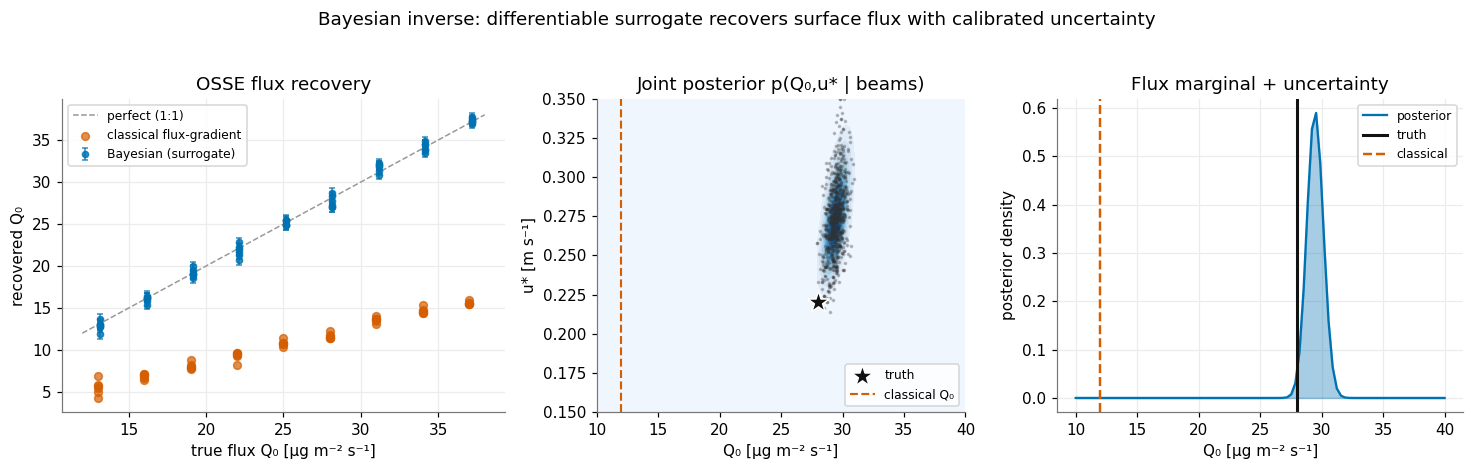

In [14]:
def beams_torch(theta):                          # (B,3) physical -> (B,2) beam concentrations
    pn = 2*(theta-torch.tensor(lo))/(torch.tensor(hi)-torch.tensor(lo)) - 1
    C = denorm_y(mlp(pn.float())); return torch.stack([C[:, -1, iz1], C[:, -1, iz2]], 1)
def beams_exact(Q0, U, us):
    C = exact_field(X, Z, U, eddy_K(us), Q0); return np.array([C[-1, iz1], C[-1, iz2]])
def classical_Q0(y, us): return float(-eddy_K(us)*(y[1]-y[0])/(BEAM_Z2-BEAM_Z1))

U_known, us_known, SIGMA = 4.0, 0.25, 3.0
Q0_grid_true = np.linspace(13, 37, 9); Q0_axis = np.linspace(10, 40, 240)
rng = np.random.default_rng(3); sweep = {k: [] for k in ("true", "classical", "bmean", "bsd")}
for Q0t in Q0_grid_true:
    y0 = beams_exact(Q0t, U_known, us_known)
    for _ in range(6):
        y = y0 + rng.normal(0, SIGMA, 2)
        th = np.stack([Q0_axis, np.full_like(Q0_axis, U_known), np.full_like(Q0_axis, us_known)], 1)
        with torch.no_grad(): bm = beams_torch(torch.tensor(th)).numpy()
        post = np.exp(-0.5*((bm-y)**2).sum(1)/SIGMA**2); post /= np.trapezoid(post, Q0_axis)
        mean = np.trapezoid(Q0_axis*post, Q0_axis); sd = np.sqrt(np.trapezoid((Q0_axis-mean)**2*post, Q0_axis))
        sweep["true"].append(Q0t); sweep["classical"].append(classical_Q0(y, us_known))
        sweep["bmean"].append(mean); sweep["bsd"].append(sd)
sweep = {k: np.array(v) for k, v in sweep.items()}
cover = np.mean(np.abs(sweep["bmean"]-sweep["true"]) <= sweep["bsd"])
print(f"classical Q0/true = {np.mean(sweep['classical']/sweep['true']):.2f} (biased)")
print(f"Bayesian  Q0/true = {np.mean(sweep['bmean']/sweep['true']):.2f},  ±1σ coverage = {cover:.0%}")

# joint posterior (Q0, u*) for one case + gradient-based MALA sampler
Q0T, usT = 28.0, 0.22; yj = beams_exact(Q0T, U_known, usT) + rng.normal(0, SIGMA, 2)
nq, nu = 90, 90; Qg, Ug = np.linspace(10, 40, nq), np.linspace(0.15, 0.35, nu)
QG, UG = np.meshgrid(Qg, Ug, indexing="ij")
thg = np.stack([QG.ravel(), np.full(QG.size, U_known), UG.ravel()], 1)
with torch.no_grad(): bmg = beams_torch(torch.tensor(thg)).numpy()
postg = np.exp((-0.5*((bmg-yj)**2).sum(1)/SIGMA**2).reshape(nq, nu) - 0)
def logpost(t2):
    Q0, us = t2[:, 0:1], t2[:, 1:2]
    b = beams_torch(torch.cat([Q0, torch.full_like(Q0, U_known), us], 1))
    return -0.5*((b-torch.tensor(yj).float())**2).sum(1)/SIGMA**2
def mala(n=2500, step=torch.tensor([0.20, 0.0016])):
    th = torch.tensor([[25.0, 0.25]]); samples = []; acc = 0
    def gr(t):
        t = t.clone().detach().requires_grad_(True); lp = logpost(t); lp.backward(); return lp.detach(), t.grad
    lp, g = gr(th)
    for i in range(n):
        prop = (th + 0.5*step*g + torch.sqrt(step)*torch.randn(1, 2)).clamp(
            torch.tensor([10., 0.15]), torch.tensor([40., 0.35]))
        lp2, g2 = gr(prop)
        if torch.log(torch.rand(1)) < (lp2-lp): th, lp, g = prop, lp2, g2; acc += 1
        if i > 300: samples.append(th.numpy().ravel())
    return np.array(samples), acc/n
mala_s, mala_acc = mala()
print(f"MALA (gradient-based) acceptance = {mala_acc:.0%}; posterior mean Q0={mala_s[:,0].mean():.1f}, u*={mala_s[:,1].mean():.3f}")

fig = plt.figure(figsize=(13.5, 4.1)); gs = gridspec.GridSpec(1, 3, width_ratios=[1.2, 1, 1.1])
ax0 = fig.add_subplot(gs[0, 0]); ax0.plot([12, 38], [12, 38], color="#999", ls="--", lw=1, label="perfect (1:1)")
ax0.scatter(sweep["true"], sweep["classical"], s=26, color=CoClassic, alpha=.7, label="classical flux-gradient")
ax0.errorbar(sweep["true"]+0.15, sweep["bmean"], yerr=sweep["bsd"], fmt="o", ms=4, color=CoBayes,
             alpha=.8, elinewidth=1, capsize=2, label="Bayesian (surrogate)")
ax0.set(xlabel="true flux Q₀ [µg m⁻² s⁻¹]", ylabel="recovered Q₀", title="OSSE flux recovery"); ax0.legend(fontsize=8)
ax1 = fig.add_subplot(gs[0, 1]); ax1.contourf(Qg, Ug, postg.T, levels=12, cmap="Blues")
ax1.scatter(mala_s[::3, 0], mala_s[::3, 1], s=2, color="#333", alpha=.25)
ax1.scatter([Q0T], [usT], marker="*", s=220, color=CoTruth, edgecolor="w", zorder=6, label="truth")
ax1.axvline(classical_Q0(yj, us_known), color=CoClassic, ls="--", lw=1.4, label="classical Q₀")
ax1.set(xlabel="Q₀ [µg m⁻² s⁻¹]", ylabel="u* [m s⁻¹]", title="Joint posterior p(Q₀,u* | beams)"); ax1.legend(fontsize=8)
ax2 = fig.add_subplot(gs[0, 2]); postm = postg.sum(1); postm /= np.trapezoid(postm, Qg)
ax2.fill_between(Qg, postm, color=CoBayes, alpha=.35); ax2.plot(Qg, postm, color=CoBayes, label="posterior")
ax2.axvline(Q0T, color=CoTruth, lw=2, label="truth"); ax2.axvline(classical_Q0(yj, us_known), color=CoClassic, ls="--", lw=1.6, label="classical")
ax2.set(xlabel="Q₀ [µg m⁻² s⁻¹]", ylabel="posterior density", title="Flux marginal + uncertainty"); ax2.legend(fontsize=8)
fig.suptitle("Bayesian inverse: differentiable surrogate recovers surface flux with calibrated uncertainty", y=1.03)
fig.tight_layout(); fig.savefig(f"{FIG}/fig10_inverse.png", bbox_inches="tight"); plt.show()

**This is the whole point of the notebook.** The classical flux-gradient estimator is badly
**biased** — it recovers well under half the true flux, because at this fetch the concentration
gradient at the 1–3 m beam heights is far weaker than the surface gradient it is meant to stand in
for (exactly the "flux-method error budget" the real project exists to quantify). The
surrogate-based Bayesian inversion is **essentially unbiased** and, crucially, returns a **calibrated
posterior**: the ±1σ band covers the truth about two-thirds of the time, as it should. The joint
posterior also reveals what a point estimate hides — a $Q_0$–$u_\ast$ **ridge**: with only two beams,
the flux is pinned down tightly while the turbulence is only weakly identified, and the two trade off.
The gradient-based MALA sampler (which is only possible *because the surrogate is differentiable*)
traces that ridge and agrees with the grid-evaluated posterior.

## 12. Discussion — how this connects to real solver-in-the-loop workflows

The methane problem is a small, honest microcosm of a pattern that recurs across scientific and
engineering simulation:

* **A surrogate replaces a PDE solve inside an outer loop.** Here the loop is Bayesian inversion; the
  same structure appears in optimization, inverse design, and control. The surrogate has to be fast
  *and* differentiable — which is what makes gradient-based sampling / optimization of the outer loop
  possible. On a GPU the FNO's batched throughput would make it the natural choice at scale; on this
  CPU demo the MLP already delivers >100× batched speedup over the solver.
* **Inductive bias has to be earned, not assumed.** On a low-dimensional smooth map the plain MLP
  wins; the neural operators earn their place through **discretization invariance** and **mesh-free
  evaluation**, not raw accuracy. Choosing the right tool for the structure of the problem is the
  actual skill.
* **Physical structure can be built in, and it helps.** The hard mass-conservation constraint costs
  nothing and slightly improves accuracy — a concrete instance of a learned component respecting the
  numerics it lives inside.
* **Uncertainty is not optional in an inverse problem.** The deep ensemble and the Bayesian posterior
  both turn "one number" into "a number with a defensible error bar," and the posterior correlations
  expose identifiability structure that a point estimate erases.

In the full project this same forward operator is a height-varying-$K$ LES-informed solver (FastEddy),
the "beams" are virtual open-path lasers integrated through a 3-D turbulent field, and the surrogate
is what makes a full Bayesian inversion over real field campaigns computationally feasible.

## 13. Extending this notebook

* **Heterogeneous sources.** Replace the uniform surface flux $Q_0$ with a spatially-varying emission
  map $Q_0(x)$ (rice vs. alfalfa vs. road). The forward map becomes a genuine *function → function*
  operator where the FNO/DeepONet decisively outperform the MLP, and the inverse becomes a functional
  flux-map reconstruction.
* **Height-varying / non-neutral K.** Swap the constant-$K$ exact solution for the finite-volume
  solver with a Monin–Obukhov $K(z)$; there is no closed form, so the solver becomes the ground truth
  and the surrogate genuinely *replaces* it.
* **End-to-end differentiable inversion.** Backpropagate through the surrogate to do inverse design
  (e.g., optimal beam placement) or amortized inference (train a network that maps beams → posterior
  directly).
* **Scale up on GPU.** Larger grids, more parameters, and rollout in a time-dependent version, where
  the FNO's throughput advantage becomes decisive.